In [1]:
%load_ext autoreload
%autoreload 2

from math import pi
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from fluxoniumcr import DATA_DIR

%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 100
plt.style.use("fluxoniumcr.plotting.paper")

In [2]:
parent_path = DATA_DIR/"EJ_allocation/EJ_control=4.00,EC_control=1.20,EL_control=0.40"

dataset4 = xr.load_dataset(
    parent_path/"EC_target=1.00,EL_target=1.00,num_targets=4.hdf5"
)
dataset3 = xr.load_dataset(
    parent_path/"EC_target=1.00,EL_target=1.00,num_targets=3.hdf5"
)
dataset2 = xr.load_dataset(
    parent_path/"EC_target=1.00,EL_target=1.00,num_targets=2.hdf5"
)

In [3]:
def plot_dataset(ax, dataset, subfig_label, xticks=False, xlabel=None, ylabels=False):
    break_indices = []
    
    for q in dataset.qubit.data:
        idx = 1 + np.nonzero(abs(dataset.f10.sel(qubit=q).diff('EJ_rel_sdev').data > 0.1))[0]
        for i in idx:
            if i not in break_indices:
                break_indices.append(i)
    break_indices = [0, *sorted(break_indices), None]
    
    for start, stop in zip(break_indices[:-1], break_indices[1:]):
        ds = dataset.isel(EJ_rel_sdev=slice(start, stop))
        f10_all = np.column_stack([ds.f10c.data, ds.f10.data]).T
        f10_sdev_all = np.column_stack([ds.f10c_sdev.data, ds.f10_sdev.data]).T

        unique_freqs, unique_indices, unique_counts = np.unique(
            f10_all[:, 0].round(decimals=4),
            return_index=True,
            return_counts=True,
        )
        x_data = ds.EJ_rel_sdev.data.copy()
        if start > 0:
            x_data[0] = dataset.EJ_rel_sdev.data[start-1:start+1].mean()
        if stop != None:
            x_data[-1] = dataset.EJ_rel_sdev.data[stop-1:stop+1].mean()

        for i, count in zip(unique_indices, unique_counts):
            if i == 0:
                color = 'C2'
            else:
                color = 'C0'

            ax.fill_between(
                    x_data,
                f10_all[i] - f10_sdev_all[i],
                f10_all[i] + f10_sdev_all[i],
                fc=color,
                alpha=0.3,
            )
            if start == 0:
                subscript = r"{\mathrm{t}" + str(i) + "}" if i != 0 else r"\mathrm{c}"
                ax.annotate(
                    "$f^{10}" + f"_{subscript}$",
                    (x_data[0], f10_all[i, 0]),
                    (1.5, 1.5),
                    textcoords="offset points",
                    c=color,
                    fontsize=plt.rcParams['ytick.labelsize'],
                    va='bottom',
                    ha='left',
                )
            for j in range(count):
                ax.plot(
                    x_data,
                    f10_all[i] + 0.1*(j - (count-1)/2),
                    c=color,
                    solid_capstyle='butt',
                )

            if i > 0:
                if start == 0:
                    subscript = r"{\mathrm{t}" + str(i) + "}"
                    ax.annotate(
                        "$2f^{10}" + f"_{subscript}" + r" - f^{10}_\mathrm{c}$",
                        (x_data[0], 2*f10_all[i, 0] - f10_all[0, 0]),
                        (1.5, 1.5),
                        textcoords="offset points",
                        c='C1',
                        fontsize=plt.rcParams['ytick.labelsize'],
                        va='bottom',
                        ha='left',
                    )

                ax.fill_between(
                    x_data,
                    2*f10_all[i] - f10_all[0] - (2*f10_sdev_all[i]**2 + f10_sdev_all[0]**2)**0.5,
                    2*f10_all[i] - f10_all[0] + (2*f10_sdev_all[i]**2 + f10_sdev_all[0]**2)**0.5,
                    fc=f"C1",
                    alpha=0.2,
                )
                ax.plot(
                    x_data,
                    2*f10_all[i] - f10_all[0],
                    c='C1',
                    ls='--',
                    solid_capstyle='butt',
                )

    ax.set_ylim(0.2 * 2*pi, 1.05 * 2*pi)
    ax.set_xlim(0.01, 0.10)

    ax.yaxis.set_major_formatter(lambda y, pos: f"{y/(2*pi):.1f}")
    ax.set_yticks(2*pi * np.array([0.2, 0.4, 0.6, 0.8, 1.0]))

    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}")
    ax.set_xticks([0.01, 0.02, 0.05, 0.10])
    ax.tick_params(axis='x', which='minor', labelbottom=False)
    ax.tick_params(axis='x', which='major', labelbottom=xticks)

    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(
        [
            1.2497300661742161,
            2.1357546439222297,
            3.6558650651620743,
            6.0664456218796285,
        ],
        ["6", "5", "4", "3"]
    )
    ax2.set_yticks(
        [
            1.6310809001075506,
            2.798494536633564,
            4.739386607054845,
        ],
        minor=True,
    )

    if ylabels:
        ax.set_ylabel("Qubit frequency [GHz]", labelpad=18)
        ax2.set_ylabel(r"Josephson energy $E_{J,\mathrm{t}}/2\pi$ [GHz]")

    for i in break_indices[1:-1]:
        pos = dataset.EJ_rel_sdev.data[i-1:i+1].mean()
        ax.axvline(
            pos,
            c=plt.rcParams['grid.color'],
            lw=plt.rcParams['grid.linewidth'],
        )
    
    if xlabel is not None:
        ax.set_xlabel(xlabel)
        
    ax.annotate(
        subfig_label,
        (0.0, 1.0),
        xytext=(-22, 0),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha='right',
        va='top',
    )

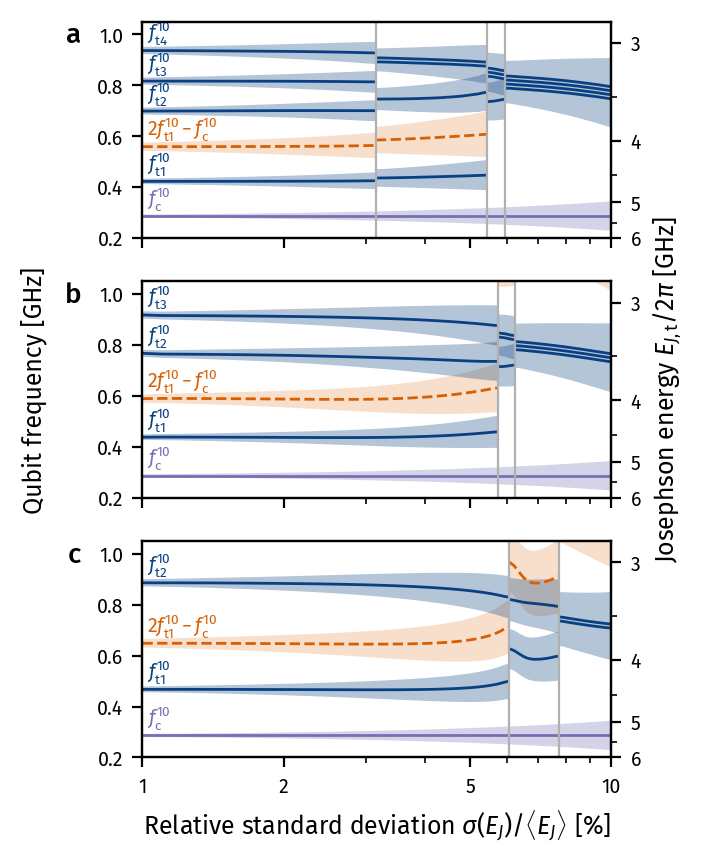

In [4]:
fig, axs = plt.subplots(
    nrows=3,
    figsize=(85/25.4, 105/25.4),
)

plot_dataset(axs[0], dataset4, "a")
plot_dataset(axs[1], dataset3, "b", ylabels=True)
plot_dataset(
    axs[2],
    dataset2,
    "c",
    xticks=True,
    xlabel=r"Relative standard deviation $\sigma(E_J)/\langle E_J\rangle$ [%]",
)

fig.subplots_adjust(
    left=0.19,
    right=0.89,
    bottom=0.1,
    top=0.99,
)

fig.savefig("ej_allocation.pdf")

In [18]:
print("EJ allocation for [GHz]")
print(
    "Square:\t\t",
    ", ".join([f"{x:.2f}" for x in dataset4.EJ.isel(EJ_rel_sdev=0)/(2*pi)])
)

print(
    "Hexagon:\t",
    ", ".join([f"{x:.2f}" for x in dataset3.EJ.isel(EJ_rel_sdev=0)/(2*pi)])
)

print(
    "Heavy-Hex:\t",
    ", ".join([f"{x:.2f}" for x in dataset2.EJ.isel(EJ_rel_sdev=0)/(2*pi)])
)

EJ allocation for [GHz]
Square:		 4.60, 3.65, 3.34, 3.06
Hexagon:	 4.53, 3.47, 3.10
Heavy-Hex:	 4.41, 3.18
